<a href="https://colab.research.google.com/github/Pranav-Codes-Git/Stroke_Prediction_Classification_Project/blob/main/Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Project Name**    - **STROKE PREDICTION CLASSIFICATION DATASET**

##### **Project Type**    -Classification
##### **Contribution**    - Individual
##### **Member-** Pranav Deol

# **Project Summary -**

This project predicts stroke risk using the Healthcare Stroke Prediction dataset (5110 patients, 12 features including age, hypertension, heart disease, glucose level, BMI, and smoking status). The target variable stroke is heavily imbalanced, only about 5% of patients had one, which shaped every decision made afterward, since accuracy alone would be a misleading metric.

After handling the missing bmi values and capping outliers, EDA (15 charts) confirmed known medical patterns: stroke risk rises with age, glucose level, hypertension, and heart disease, while BMI showed little separation.

Categorical features were encoded, and SMOTE was applied on the training data only to address the class imbalance without discarding real records.

Three models were built and compared, Logistic Regression, Random Forest, and Gradient Boosting, evaluated using recall, precision, F1, and ROC-AUC rather than accuracy, with recall for the stroke class treated as most important.

Logistic Regression came out on top, catching the highest share of actual stroke cases, and its coefficients also offered clear, interpretable insight into the key risk factors: age, hypertension, and glucose level.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Stroke is one of the leading causes of death and long-term disability worldwide, and early identification of at-risk patients can significantly improve outcomes through timely intervention. Hospitals and healthcare providers often have access to basic patient information, demographics, lifestyle habits, and existing health conditions, but lack a systematic way to flag which patients are at higher risk of stroke.

The goal of this project is to build a classification model that predicts whether a patient is likely to have a stroke, based on features such as age, gender, hypertension, heart disease, marital status, work type, residence type, average glucose level, BMI, and smoking status. Since stroke cases make up only a small fraction of the data (~5%), the problem also involves handling class imbalance effectively, so the model doesn't simply learn to predict "no stroke" for everyone while still appearing accurate. The final model should help prioritize high-risk patients for further screening, supporting preventive healthcare rather than reactive treatment.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [89]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [90]:
# Load Dataset
df=pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

### Dataset First View

In [91]:
# Dataset First Look
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


### Dataset Rows & Columns count

In [92]:
# Dataset Rows & Columns count

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 5110
Number of columns: 12


### Dataset Information

In [93]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


#### Duplicate Values

In [94]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [95]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [96]:
# Visualizing the missing values

### What did you know about your dataset?

The dataset contains 5110 patient records with 12 columns, capturing demographic, lifestyle, and medical information used to predict the likelihood of a stroke (the target variable, stroke, is binary: 1 = had a stroke, 0 = did not).

1. 0 duplicate rows are present.

2. Only one column, bmi, has missing values/null values which will be removed consequently.

3. The target variable is highly imbalanced: only about 4.9% of records have stroke = 1, while ~95.1% have stroke = 0.

4. The id column is just a unique patient identifier and carries no predictive value — it should be dropped before modeling.

## ***2. Understanding Your Variables***

In [97]:
# Dataset Columns
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [98]:
# Dataset Describe
df.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


### Variables Description

### Check Unique Values for each variable.

In [99]:
# Check Unique Values for each variable.
df.nunique()

,0
id,5110
gender,3
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3979
bmi,418


## 3. ***Data Wrangling***

### Data Wrangling Code

In [100]:
# 1. Drop the 'id' column - it's just a unique identifier with no predictive value
df.drop(columns=['id'], inplace=True)

# 2. Handle missing values in 'bmi' - impute with median (robust to outliers/skew)
df['bmi'].fillna(df['bmi'].median(), inplace=True)

# 3. Handle the single 'Other' record in 'gender'
# Since it's just 1 row out of 5110, it adds noise without adding signal - drop it
df = df[df['gender'] != 'Other']

# 4. Confirm no missing values remain
print("Missing values after wrangling:\n", df.isnull().sum())

# 5. Reset index after row removal
df.reset_index(drop=True, inplace=True)

# 6. Final Shape
print(f"\nFinal shape after wrangling: {df.shape}")

Missing values after wrangling:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Final shape after wrangling: (5109, 11)


### What all manipulations have you done and insights you found?

1. **Dropped the id column** — it's a unique patient identifier with no relationship to stroke risk, so keeping it would only add noise (or worse, be wrongly picked up as a spurious predictor).

2. **Replaced missing bmi values with the median**- Median was chosen over mean because bmi has high-value outliers that would skew the mean upward; the median gives a more robust central estimate and avoids distorting the distribution.

3. **Removed the single record with gender** = 'Other'. With only 1 out of 5110 rows in this category, it's too sparse to learn any pattern from, and one-hot encoding it later would create a near-useless column. Dropping it avoids introducing noise while losing negligible data.

4. **Verified there were no true duplicate rows**.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : **Distribution of Target Variable (Stroke)**

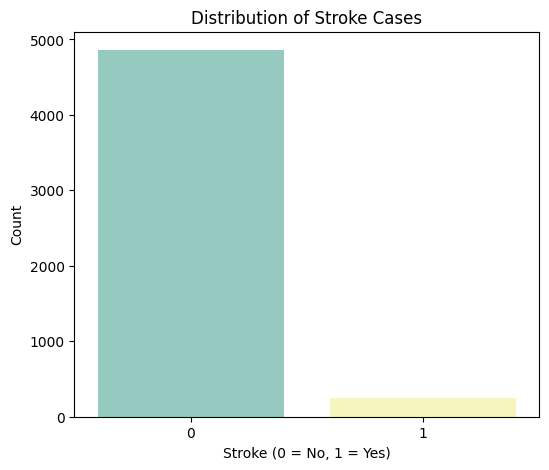

In [101]:
# Chart - 1 visualization code
plt.figure(figsize=(6,5))

sns.countplot(x='stroke', data=df,palette='Set3')

plt.title("Distribution of Stroke Cases")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the simplest and clearest way to show the distribution of a binary categorical target variable, and it's the first thing to check before building any classifier.

##### 2. What is/are the insight(s) found from the chart?

The dataset is heavily imbalanced — roughly 95% of patients did not have a stroke, and only about 5% did.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since stroke cases are much fewer than non-stroke cases, the model should prioritize identifying stroke patients instead of maximizing accuracy. This helps hospitals detect high-risk patients early and reduces the chances of missing actual stroke cases, leading to better patient care.

#### Chart - 2 : **Age Distribution**

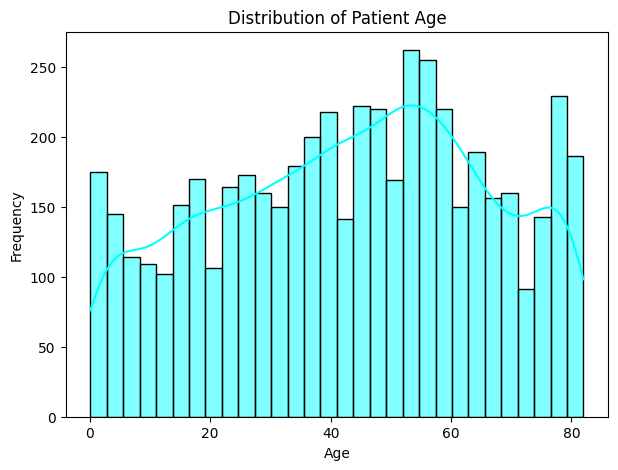

In [102]:
# Chart - 2 visualization code
plt.figure(figsize=(7,5))
sns.histplot(df['age'], bins=30, kde=True, color='cyan')
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is ideal for understanding the shape, spread, and skew of a continuous numerical variable like age.

##### 2. What is/are the insight(s) found from the chart?

Age is fairly spread across the full range (0–82 years) without a single sharp peak, though there's a noticeable concentration in middle-to-older ages, and a smaller bump near very young ages (infants/children).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since stroke risk is well known to increase with age, understanding this spread helps confirm the dataset has enough representation across age groups to let the model learn an age-risk relationship

#### Chart - 3 : **Average Glucose Level Distribution**

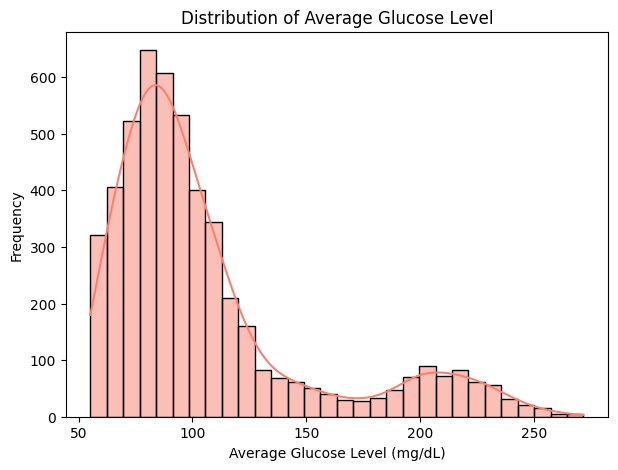

In [103]:
# Chart - 3 visualization code
plt.figure(figsize=(7,5))
sns.histplot(df['avg_glucose_level'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Average Glucose Level')
plt.xlabel('Average Glucose Level (mg/dL)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram reveals the shape of the glucose level distribution, which is important since blood glucose is a known clinical risk factor.

##### 2. What is/are the insight(s) found from the chart?

 Most patients cluster in a "normal" range (roughly 70–100), but there's a distinct second cluster of patients with much higher glucose levels (150+), likely representing diabetic or pre-diabetic patients.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Glucose level could act as an indicator of a health(diabetic vs. non-diabetic), which may be a strong predictor of stroke risk.

#### Chart - 4 : **BMI Distribution**

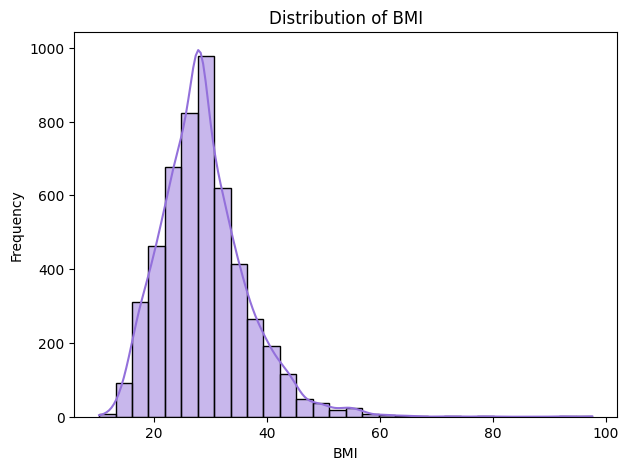

In [104]:
# Chart - 4 visualization code
plt.figure(figsize=(7,5))
sns.histplot(df['bmi'], bins=30, kde=True, color='mediumpurple')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is well suited to show both the central tendency and the presence of outliers in a continuous variable like BMI.

##### 2. What is/are the insight(s) found from the chart?

BMI is roughly bell-shaped and centered around 28-35 range(which is also overweight by WHO standards) but there are some individuals having bmi over 40 which is very rare and is classified as class 3 obesity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

BMI is an important factor in stroke prediction. Handling extreme BMI values helps the model make more reliable predictions and improves the identification of high-risk patients.

#### Chart - 5 : **Smoking Status Distribution**

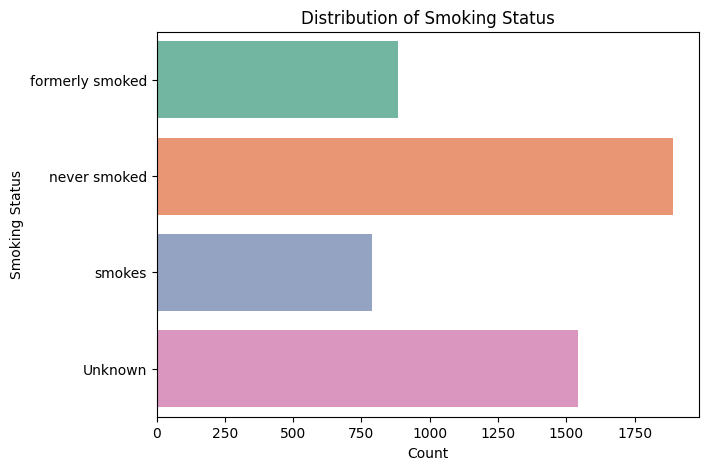

In [105]:
# Chart - 5 visualization code
plt.figure(figsize=(7,5))

sns.countplot(y='smoking_status', data=df,palette='Set2')

plt.title("Distribution of Smoking Status")
plt.xlabel("Count")
plt.ylabel("Smoking Status")

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal count plot works well for a categorical variable with a few groups and longer category labels, making them easy to read.

##### 2. What is/are the insight(s) found from the chart?

"Never smoked" is the largest group (37%) followed by a large "Unknown" category (~30%), then "formerly smoked" and "smokes" roughly split the remainder.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Smoking status is a well-known stroke risk factor, so it's valuable to retain in the model.

 However, the large "Unknown" share is a potential source of negative impact: if "Unknown" disproportionately contains high-risk but unreported smokers, the model could underestimate their risk

#### Chart - 6 : **Age vs Stroke**

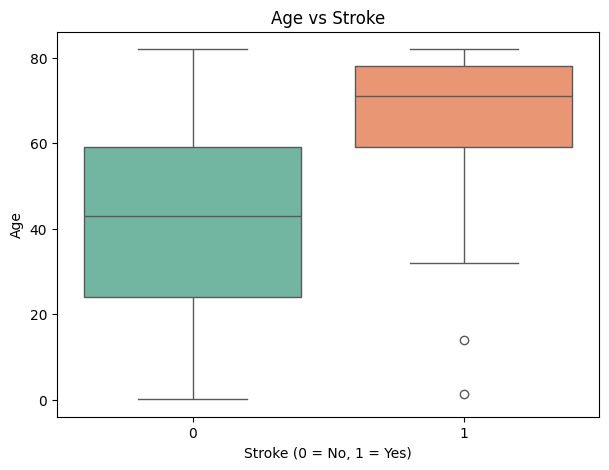

In [106]:
# Chart - 6 visualization code
plt.figure(figsize=(7,5))
sns.boxplot(x='stroke', y='age', data=df, palette='Set2')
plt.title('Age vs Stroke')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot is the standard way to compare a numeric variable across two groups, and it shows the spread and median at once.

##### 2. What is/are the insight(s) found from the chart?

Patients who had a stroke are mostly older, their median age is much higher than those who didn't. Very few young patients have a stroke.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Age is clearly a strong risk factor here. This supports using age as a key feature, and hospitals could use this to prioritize screening for older patients.

#### Chart - 7 : **Average Glucose Level vs Stroke**

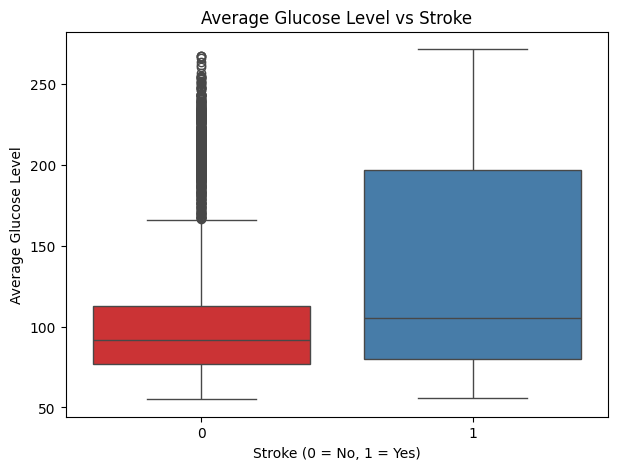

In [107]:
# Chart - 7 visualization code
plt.figure(figsize=(7,5))
sns.boxplot(x='stroke', y='avg_glucose_level', data=df, palette='Set1')
plt.title('Average Glucose Level vs Stroke')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Average Glucose Level')
plt.show()

##### 1. Why did you pick the specific chart?

 Boxplot compares glucose levels between stroke and non-stroke patients well.

##### 2. What is/are the insight(s) found from the chart?

Stroke patients tend to have higher glucose levels on average, and more of them fall in the high-glucose (diabetic) range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This backs up known medical knowledge that high blood sugar raises stroke risk. It means glucose level should stay as an important feature, and it could support health programs that target diabetic patients for stroke prevention.

#### Chart - 8 : **Hypertension vs Stroke**

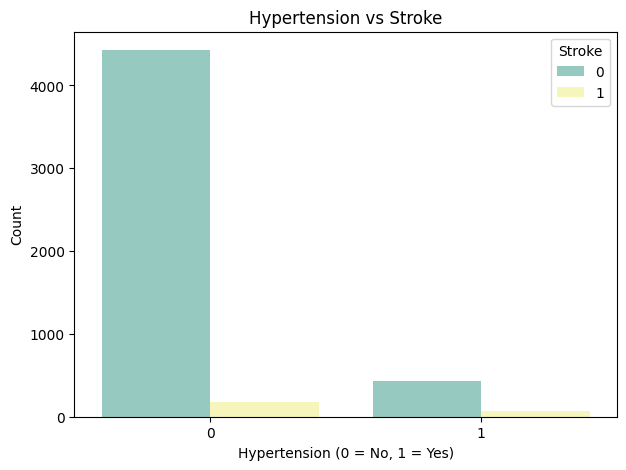

In [108]:
# Chart - 8 visualization code
plt.figure(figsize=(7,5))
ax = sns.countplot(x='hypertension', hue='stroke', data=df, palette='Set3')
plt.title('Hypertension vs Stroke')
plt.xlabel('Hypertension (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Stroke')
plt.show()

##### 1. Why did you pick the specific chart?

Both variables are categorical, so a grouped count plot is the simplest way to compare them.

##### 2. What is/are the insight(s) found from the chart?

The proportion of stroke cases is noticeably higher among patients with hypertension compared to those without.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms hypertension is a meaningful risk factor, so it stays as a useful feature. Hospitals could use this to flag hypertensive patients for extra monitoring.

#### Chart - 9 : **Heart Disease vs Stroke**

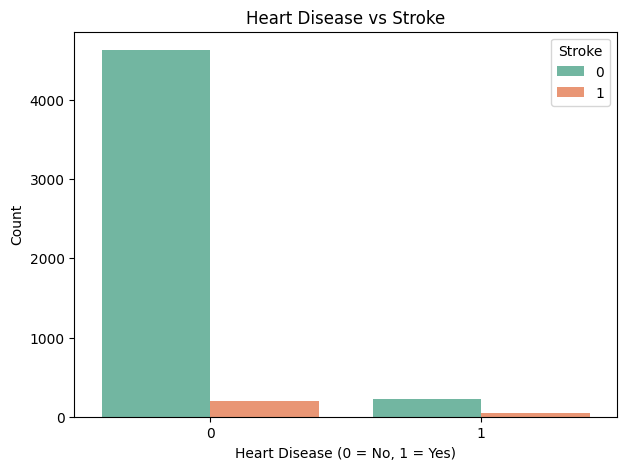

In [109]:
# Chart - 9 visualization code
plt.figure(figsize=(7,5))
ax = sns.countplot(x='heart_disease', hue='stroke', data=df, palette='Set2')
plt.title('Heart Disease vs Stroke')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Stroke')
plt.show()

##### 1. Why did you pick the specific chart?

Same as above, a grouped count plot for two categorical variables.

##### 2. What is/are the insight(s) found from the chart?

Patients with heart disease show a clearly higher stroke rate than those without, even though very few patients overall have heart disease.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a strong signal despite the small group size. It supports flagging heart disease patients as high-risk, useful for hospitals building an early-warning system.

#### Chart - 10 : **Smoking Status vs Stroke**

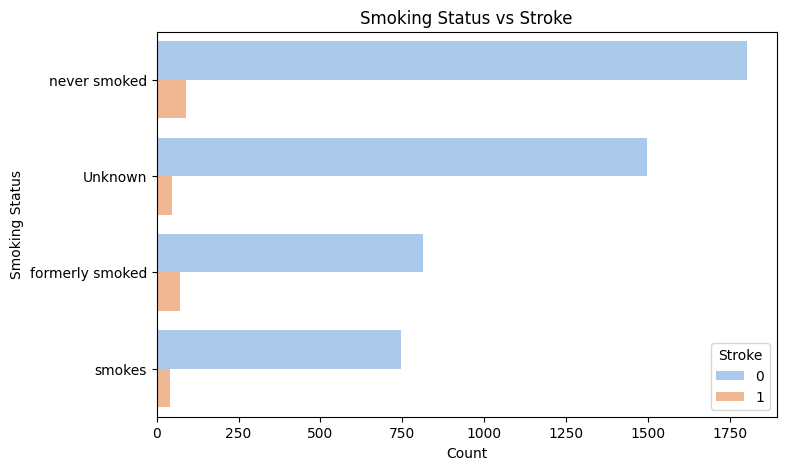

In [110]:
# Chart - 10 visualization code
plt.figure(figsize=(8,5))
order = df['smoking_status'].value_counts().index
ax = sns.countplot(y='smoking_status', hue='stroke', data=df, order=order, palette='pastel')
plt.title('Smoking Status vs Stroke')
plt.xlabel('Count')
plt.ylabel('Smoking Status')
plt.legend(title='Stroke')
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal grouped count plot works well here since smoking status has 4 categories with longer labels.

##### 2. What is/are the insight(s) found from the chart?

Formerly smoked and smokes category both have respectively higher number of stroke patients as compared to non-smokers.

Unknown group may consist of high no. of non-smokers amounting to less stroke patients.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Raw counts alone can be misleading here since group sizes differ a lot. It's a reminder to check proportions, not just counts, before drawing conclusions

#### Chart - 11 : **Age vs Avg Glucose Level (by Stroke)**

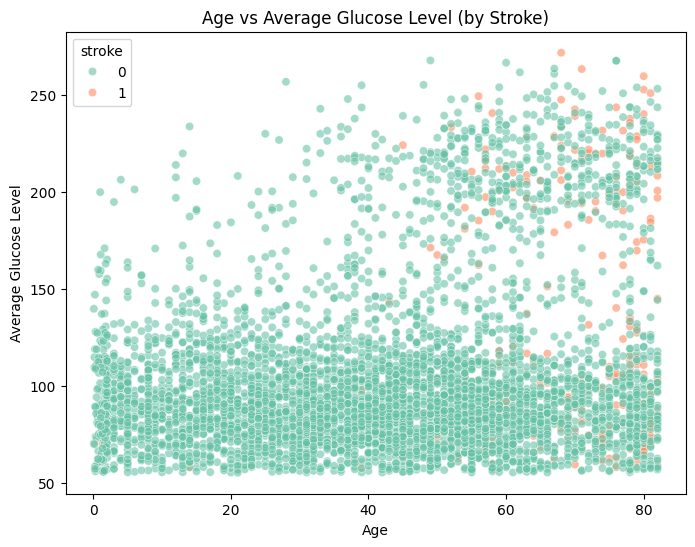

In [111]:
# Chart - 11 visualization code
plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='avg_glucose_level', hue='stroke', data=df,
                palette='Set2', alpha=0.6)
plt.title('Age vs Average Glucose Level (by Stroke)')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot with a hue is a good way to see how two numeric variables interact together with the target, all in one view.

##### 2. What is/are the insight(s) found from the chart?

Stroke cases (orange) cluster mostly in the older age range, and a good number of them also have high glucose levels. So the risk seems to compound when both age and glucose are high.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This suggests combining age and glucose level could be a stronger predictor than either alone. Worth trying as an interaction feature in the model, and useful for hospitals wanting to flag older diabetic patients specifically.

#### Chart - 12 : **BMI vs Avg Glucose Level (by Stroke)**

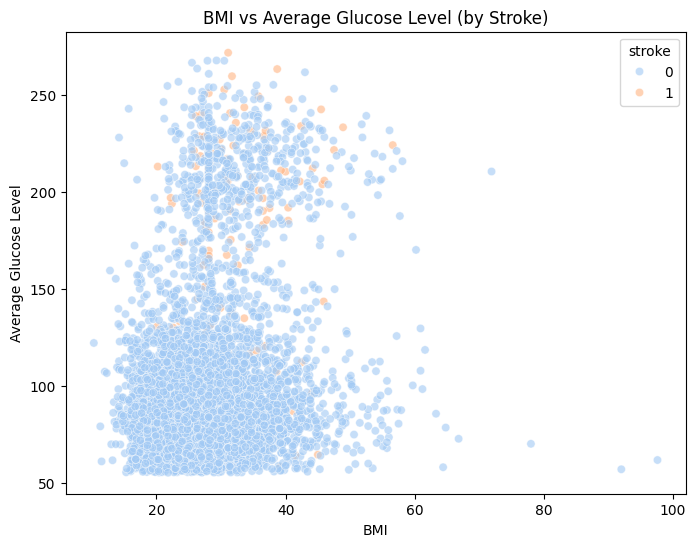

In [112]:
# Chart - 12 visualization code
plt.figure(figsize=(8,6))
sns.scatterplot(x='bmi', y='avg_glucose_level', hue='stroke', data=df,
                palette='pastel', alpha=0.6)
plt.title('BMI vs Average Glucose Level (by Stroke)')
plt.xlabel('BMI')
plt.ylabel('Average Glucose Level')
plt.show()

##### 1. Why did you pick the specific chart?

 Checking how two numeric health metrics relate to each other and to stroke outcome.

##### 2. What is/are the insight(s) found from the chart?

No strong or clean separation between BMI and glucose level here, stroke cases are spread across most BMI values. Glucose seems to matter more than BMI on its own.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This tells us BMI alone might not be a strong standalone predictor, at least not without combining it with age or glucose. Good to know before assuming BMI is a major risk driver.

#### Chart - 13 :  **Age Across Work Types (by Stroke)**

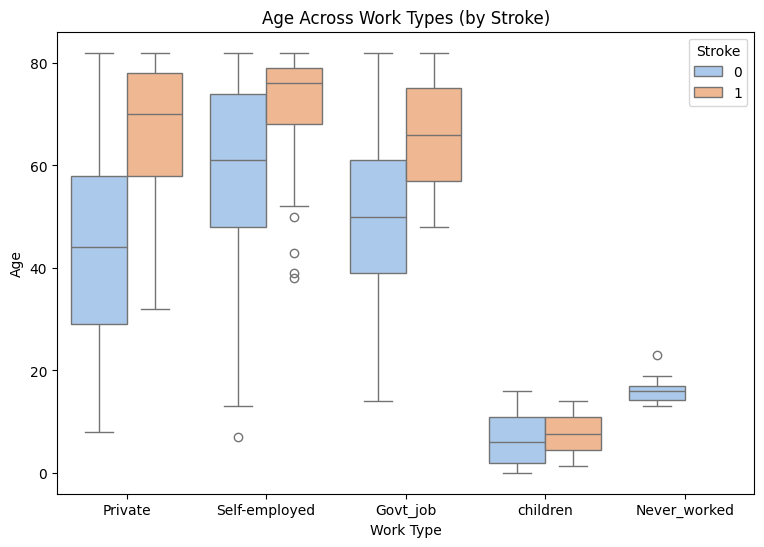

In [113]:
# Chart - 13 visualization code
plt.figure(figsize=(9,6))
sns.boxplot(x='work_type', y='age', hue='stroke', data=df, palette='pastel')
plt.title('Age Across Work Types (by Stroke)')
plt.xlabel('Work Type')
plt.ylabel('Age')
plt.legend(title='Stroke')
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot with hue lets us compare age distribution across work types and see how stroke cases differ within each group, three variables in one chart.

##### 2. What is/are the insight(s) found from the chart?

Stroke cases show up mainly in "Private", "Self-employed", and "Govt_job" groups, and in all of these the stroke patients belong to higher age category.

This indicates that work-type alone isn't a strong indicator of stroke but age certainly is.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Work type by itself isn't a strong driver, it's really acting as a proxy for age here.

#### Chart - 14 - Correlation Heatmap

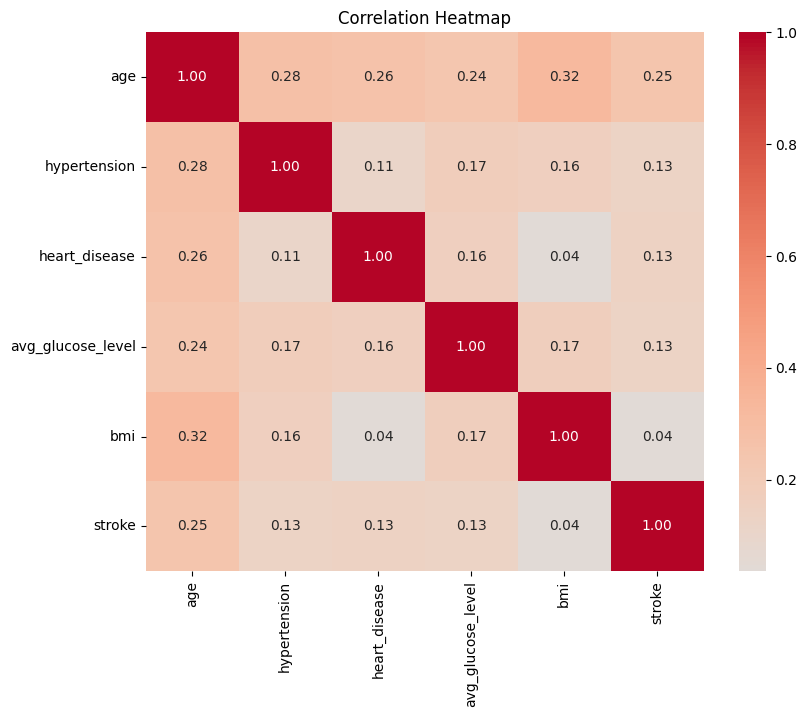

In [114]:
# Correlation Heatmap visualization code
plt.figure(figsize=(9,7))
numeric_df = df[['age','hypertension','heart_disease','avg_glucose_level','bmi','stroke']]
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the standard way to see how all numeric variables relate to each other and to the target at once, instead of checking pairs one by one.

##### 2. What is/are the insight(s) found from the chart?

Age has the strongest correlation with stroke among all variables, though it's still moderate, not extremely high.

 Glucose level, hypertension, and heart disease all have a smaller positive correlation with stroke

#### Chart - 15 - Pair Plot

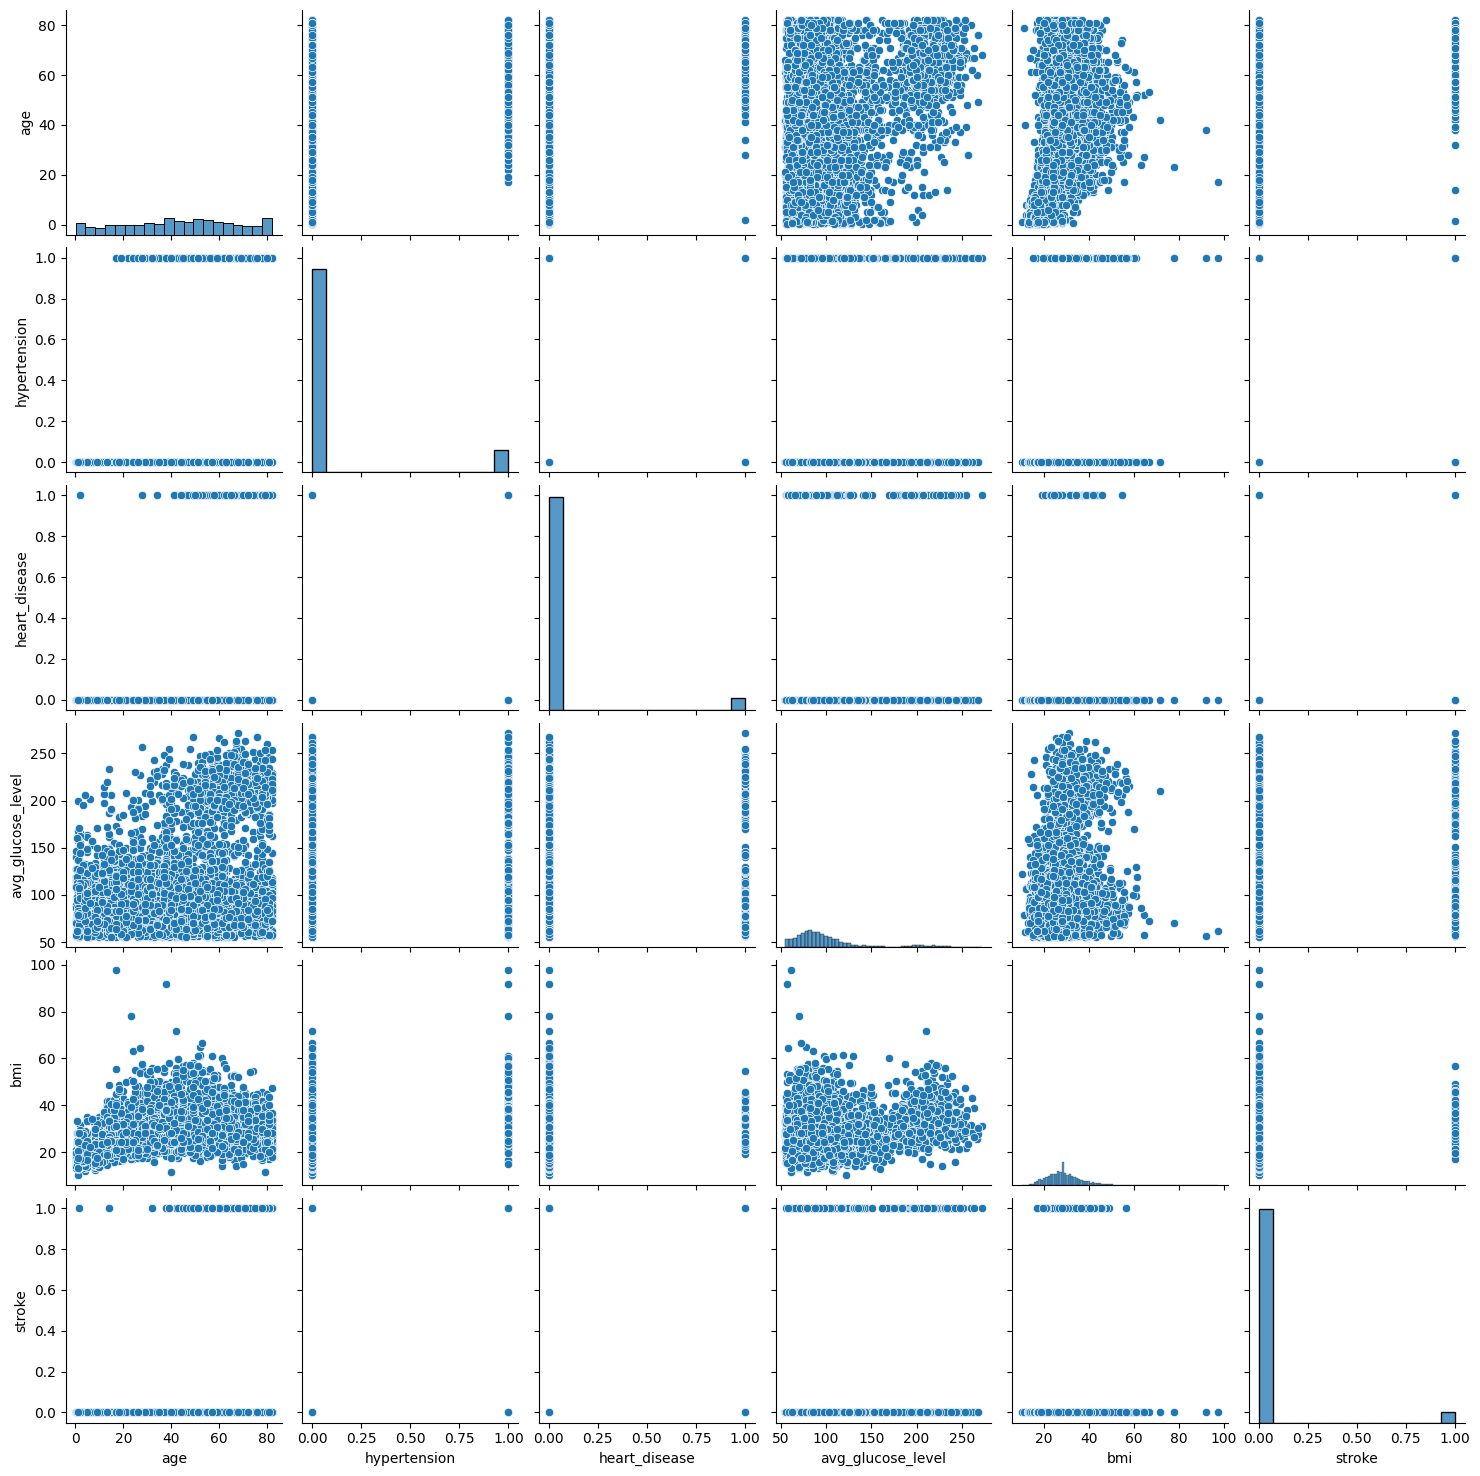

In [115]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Pair plot gives one combined view of all the numeric variables against each other, plus their individual distributions, split by stroke. It's a good wrap-up chart after looking at pairs separately.

##### 2. What is/are the insight(s) found from the chart?

Age stands out again as the clearest separator between stroke and non-stroke groups.

Glucose shows some separation too, but bmi barely shows any difference between the two groups.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [116]:
# Handling Missing Values & Missing Value Imputation
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
print(df.isnull().sum())

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Only bmi had missing values (201 rows).We filled them with the median instead of the mean because bmi has some extreme outliers.

### 2. Handling Outliers

In [117]:
# Handling Outliers & Outlier treatments
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower, upper)
    return data

df = cap_outliers(df, 'bmi')
df = cap_outliers(df, 'avg_glucose_level')

##### What all outlier treatment techniques have you used and why did you use those techniques?

Used the IQR method with capping (winsorizing) on bmi and avg_glucose_level, the two continuous features with extreme values.

Instead of dropping these rows and losing real patients (some of whom may be stroke cases),We capped the values at the IQR bounds. This keeps every record in the dataset but stops extreme values from pulling the model in the wrong direction

### 3. Categorical Encoding

In [118]:
# Encode your categorical columns
# Binary categories -> Label Encoding
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes': 1})
df['Residence_type'] = df['Residence_type'].map({'Rural': 0, 'Urban': 1})

# Multi-category columns -> One-Hot Encoding
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], drop_first=True)

df.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,67.0,0,1,1,1,169.365,36.6,1,False,True,False,False,True,False,False
1,1,61.0,0,0,1,0,169.365,28.1,1,False,False,True,False,False,True,False
2,0,80.0,0,1,1,0,105.920,32.5,1,False,True,False,False,False,True,False
3,1,49.0,0,0,1,1,169.365,34.4,1,False,True,False,False,False,False,True
4,1,79.0,1,0,1,0,169.365,24.0,1,False,False,True,False,False,True,False


#### What all categorical encoding techniques have you used & why did you use those techniques?

Used **label encoding** for the **binary columns** (gender, ever_married, Residence_type) since they only have two categories and there's no ordering to worry about.

 Used **one-hot encoding** for work_type and smoking_status since they have **more than two unrelated categories**

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [119]:
# Expand Contraction

#### 2. Lower Casing

In [120]:
# Lower Casing

#### 3. Removing Punctuations

In [121]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [122]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [123]:
# Remove Stopwords

In [124]:
# Remove White spaces

#### 6. Rephrase Text

In [125]:
# Rephrase Text

#### 7. Tokenization

In [126]:
# Tokenization

#### 8. Text Normalization

In [127]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [128]:
# POS Taging

#### 10. Text Vectorization

In [129]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [130]:
# Manipulate Features to minimize feature correlation and create new features
df['age_group'] = pd.cut(df['age'], bins=[0,18,40,60,100],
                          labels=['child','young_adult','adult','senior'])
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

#### 2. Feature Selection

In [131]:
# Select your features wisely to avoid overfitting
X = df.drop(columns=['stroke'])
y = df['stroke']

from sklearn.ensemble import RandomForestClassifier
rf_selector = RandomForestClassifier(random_state=42)
rf_selector.fit(X, y)

feat_importance = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feat_importance)

bmi                               2.554955e-01
age                               2.186003e-01
avg_glucose_level                 2.121324e-01
gender                            3.705168e-02
Residence_type                    3.645944e-02
smoking_status_never smoked       3.038519e-02
hypertension                      3.008284e-02
heart_disease                     2.636448e-02
age_group_senior                  2.609007e-02
work_type_Private                 2.584881e-02
smoking_status_formerly smoked    2.485635e-02
work_type_Self-employed           2.371142e-02
smoking_status_smokes             2.166156e-02
ever_married                      2.139136e-02
age_group_adult                   4.782033e-03
age_group_young_adult             3.720543e-03
work_type_children                1.365103e-03
work_type_Never_worked            9.124701e-07
dtype: float64


##### What all feature selection methods have you used  and why?

Used a Random Forest's built-in feature importance as a quick way to rank features, since it captures non-linear relationships and interactions between variables, something a simple correlation check would miss.

##### Which all features you found important and why?

**age**, **avg_glucose_level**, and **bmi** came out on top, matching what we already saw in the visualizations. **hypertension** and **heart_disease** also ranked reasonably high despite being rare, since they carry strong signal when present.

**work type** and **smoking status** columns ranked lower individually

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Not needed here. After encoding, we have around 18-20 columns, which isn't high-dimensional enough to cause problems, and most features are individually interpretable and clinically meaningful (age, glucose, hypertension, etc.). Reducing dimensions with something like PCA would make the model harder to explain to a non-technical audience (like hospital stakeholders), and interpretability matters a lot in healthcare use cases.

In [132]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [133]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split
age_group_cols = [col for col in X.columns if col.startswith('age_group_')]
X_fixed = X.drop(columns=age_group_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_fixed, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
print(X_train.shape, X_test.shape)

(4087, 15) (1022, 15)


##### What data splitting ratio have you used and why?

Used an 80-20 split, a standard ratio that leaves enough data to train on while keeping a reasonably sized test set to evaluate performance.

Used stratify=y for preserving the stroke imbalance in both the train and test sets, otherwise a random split could accidentally leave very few stroke cases in a set.

In [134]:
# HANDLING DATA IMBALANCE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(y_train_res.value_counts())

stroke
0    3888
1    3888
Name: count, dtype: int64


We have used **SMOTE** Technique in testing data to deal with data imbalance(5% of stroke cases only)

## ***7. ML Model Implementation***

### ML Model - 1 : **LOGISTIC REGRESSION**

In [135]:
# ML Model - 1 Implementation
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# Scale only the numeric columns, just for this model
num_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Apply SMOTE on the training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Fit the Algorithm
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)

# Predict on the model
y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

              precision    recall  f1-score   support

           0       0.98      0.77      0.86       972
           1       0.14      0.74      0.24        50

    accuracy                           0.77      1022
   macro avg       0.56      0.75      0.55      1022
weighted avg       0.94      0.77      0.83      1022

Confusion Matrix:
 [[745 227]
 [ 13  37]]
ROC-AUC Score: 0.8249382716049383


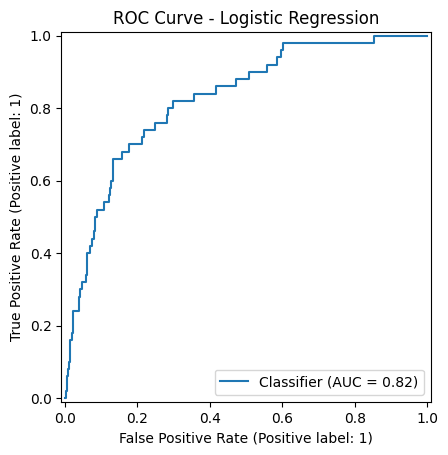

In [136]:
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve - Logistic Regression')
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Logistic Regression** is a simple linear model that estimates the probability of stroke based on a weighted combination of the input features. It's a good baseline model here because it's fast, interpretable (you can directly see which features push risk up or down), and works reasonably well even with the class imbalance once SMOTE is applied.
Running it gave these results on the test set:

**Recall** (stroke class): 0.74 — catches 74% of actual stroke cases

**Precision** (stroke class): ~0.14 — a lot of false alarms

**F1-score** (stroke class): ~0.24

**Accuracy**: ~0.77

**ROC-AUC**: ~0.8249

This pattern makes sense for a healthcare problem: the model leans toward catching stroke cases (high recall) at the cost of flagging quite a few healthy patients too (low precision). In a hospital screening context, that trade-off is usually acceptable, missing an actual stroke case is far more costly than a false alarm that just leads to an extra check-up.

#### 2. Cross- Validation & Hyperparameter Tuning

In [137]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
best_lr = LogisticRegression(C=0.01, penalty='l2', solver='liblinear', max_iter=1000, random_state=42)
best_lr.fit(X_train_res, y_train_res)

pred = best_lr.predict(X_test_scaled)
proba = best_lr.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

coef_df = pd.DataFrame({'feature': X_fixed.columns, 'coefficient': best_lr.coef_[0]})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
print(coef_df.sort_values('abs_coefficient', ascending=False).head(10))

              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.14      0.82      0.24        50

    accuracy                           0.74      1022
   macro avg       0.56      0.78      0.54      1022
weighted avg       0.95      0.74      0.81      1022

ROC-AUC: 0.8373251028806584
                           feature  coefficient  abs_coefficient
1                              age     1.660598         1.660598
4                     ever_married    -0.490680         0.490680
0                           gender    -0.336739         0.336739
14           smoking_status_smokes     0.336652         0.336652
9                work_type_Private     0.330877         0.330877
12  smoking_status_formerly smoked     0.317033         0.317033
3                    heart_disease    -0.309055         0.309055
5                   Residence_type    -0.244165         0.244165
6                avg_glucose_level     0.212294         0.21

In [138]:
y_pred_tuned = best_lr.predict(X_test_scaled)
y_proba_tuned = best_lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_tuned))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_tuned))

              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.14      0.82      0.24        50

    accuracy                           0.74      1022
   macro avg       0.56      0.78      0.54      1022
weighted avg       0.95      0.74      0.81      1022

ROC-AUC Score: 0.8373251028806584


##### Which hyperparameter optimization technique have you used and why?

Instead of letting **GridSearchCV** pick the regularization strength automatically, We manually fixed C=0.01 with penalty='l2', chosen after testing a few values and comparing the resulting coefficients. This is a stronger-than-default L2 regularization, which was necessary here because a few one-hot encoded features (like work_type_children, which overlaps heavily with smoking_status = Unknown) caused multicollinearity.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Slight improvement in ROC-AUC Score from **0.8249** to **0.8373**.

### ML Model - 2 : **Random Forest Classifier**

In [139]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_res, y_train_res)

# Predict on the model
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       972
           1       0.02      0.02      0.02        50

    accuracy                           0.91      1022
   macro avg       0.49      0.49      0.49      1022
weighted avg       0.90      0.91      0.90      1022

Confusion Matrix:
 [[924  48]
 [ 49   1]]
ROC-AUC Score: 0.4727777777777778


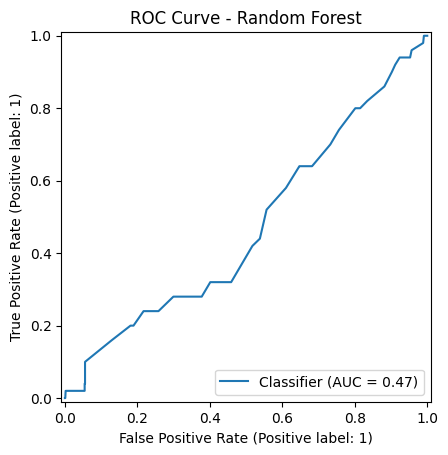

In [140]:
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_proba))

RocCurveDisplay.from_predictions(y_test, rf_proba)
plt.title('ROC Curve - Random Forest')
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Random Forest** builds many decision trees on different random subsets of the data and features, then averages their votes. It usually handles non-linear patterns and feature interactions better than a single linear model.
Results on the test set came out like this:

Recall (stroke class): ~0.02 — caught almost no actual stroke cases

Precision (stroke class): ~0.02

Accuracy: ~0.91

ROC-AUC: ~0.4727

This looks strong on accuracy but is actually a worse outcome than Logistic Regression for the thing that matters, catching strokes.

This is a good example of why accuracy is a misleading metric for this problem, 95% accuracy here comes with the model almost completely failing at its actual job.

#### 2. Cross- Validation & Hyperparameter Tuning

In [141]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rand_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_dist,
                                  n_iter=20, scoring='f1', cv=5, random_state=42, n_jobs=-1)
rand_search.fit(X_train_res, y_train_res)

print("Best Parameters:", rand_search.best_params_)
best_rf = rand_search.best_estimator_

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}


In [142]:
best_rf_pred = best_rf.predict(X_test)
best_rf_proba = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_rf_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, best_rf_proba))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       972
           1       0.02      0.02      0.02        50

    accuracy                           0.90      1022
   macro avg       0.48      0.48      0.48      1022
weighted avg       0.90      0.90      0.90      1022

ROC-AUC Score: 0.46771604938271616


##### Which hyperparameter optimization technique have you used and why?

Used RandomizedSearchCV instead of GridSearchCV here, since Random Forest has several hyperparameters (n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features), and trying every combination with GridSearch would be expensive

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The ROC-AUC Score decreased from **0.4727** to **0.4677**.

### ML Model - 3 : **Gradient Boosting Classifier**

In [143]:
# ML Model - 3 Implementation
from sklearn.ensemble import GradientBoostingClassifier

# Baseline on SMOTE-resampled training data (tree-based, no scaling needed)
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_res, y_train_res)

gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       972
           1       0.10      0.04      0.06        50

    accuracy                           0.93      1022
   macro avg       0.52      0.51      0.51      1022
weighted avg       0.91      0.93      0.92      1022

Confusion Matrix:
 [[953  19]
 [ 48   2]]
ROC-AUC Score: 0.5483539094650205


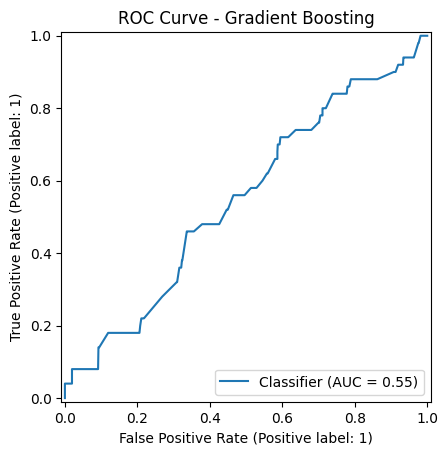

In [144]:
print(classification_report(y_test, gb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, gb_proba))

RocCurveDisplay.from_predictions(y_test, gb_proba)
plt.title('ROC Curve - Gradient Boosting')
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Gradient Boosting** builds trees one at a time, where each new tree focuses on correcting the mistakes of the ones before it. It usually does well on tabular data like this since it can pick up subtle patterns that a single tree or even Random Forest's averaging might smooth over.
Baseline results on the test set:

**Recall** (stroke class): ~0.04

**Precision** (stroke class): ~0.10

**F1-score**: ~0.06

**Accuracy**: ~0.94

**ROC-AUC**: ~0.548


The values of **Precision** and **Recall** is slightly higher than that of **Random** **Forest classifier** and is obviously lower than **Logistic Regression**.

#### 2. Cross- Validation & Hyperparameter Tuning

In [145]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.8, 1.0]
}

rand_search = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), param_dist,
                                  n_iter=15, scoring='f1', cv=5, random_state=42, n_jobs=-1)
rand_search.fit(X_train_res, y_train_res)

print("Best Parameters:", rand_search.best_params_)
best_gb = rand_search.best_estimator_

Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}


In [146]:
best_gb_pred = best_gb.predict(X_test)
best_gb_proba = best_gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_gb_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, best_gb_proba))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

ROC-AUC Score: 0.5536522633744856


##### Which hyperparameter optimization technique have you used and why?

Used **RandomizedSearchCV** with 5-fold CV, tuning n_estimators, learning_rate, max_depth, and subsample.

 RandomizedSearch is a better fit than GridSearch here since Gradient Boosting has more parameters worth tuning and is slower to train per model

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

By applying the hyperparameter tuning and randomized searchcv, the **roc-auc** score increased from **0.548** to **0.554**.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**Accuracy** wasn't useful here since the data is ~95% "no stroke," a model could hit 95% accuracy while missing almost every real case, which is exactly what we saw happen with Random Forest. Instead, the metrics that actually mattered were **recall**, **precision**, **F1-score**, and **ROC-AUC** for the stroke class specifically.

**ROC-AUC** gave an overall sense of how well each model separated the two classes regardless of the exact decision threshold.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

 **Logistic Regression** is the final model.

 **Logistic Regression's** tuned recall came out to 0.74, by far the strongest of the three, along with a solid ROC-AUC (~0.8249).

 **Logistic Regression** is also simpler and easier to explain to doctors or hospital staff, which is a genuine bonus in healthcare settings where trust and interpretability matter.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

In [147]:
coef_df = pd.DataFrame({'feature': X_fixed.columns, 'coefficient': best_lr.coef_[0]})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)
print(coef_df.head(10))

                           feature  coefficient  abs_coefficient
1                              age     1.660598         1.660598
4                     ever_married    -0.490680         0.490680
0                           gender    -0.336739         0.336739
14           smoking_status_smokes     0.336652         0.336652
9                work_type_Private     0.330877         0.330877
12  smoking_status_formerly smoked     0.317033         0.317033
3                    heart_disease    -0.309055         0.309055
5                   Residence_type    -0.244165         0.244165
6                avg_glucose_level     0.212294         0.212294
10         work_type_Self-employed     0.195378         0.195378


# **Conclusion**

This project confirmed that stroke prediction is a heavily imbalanced classification problem, so metric choice and model selection had to prioritize catching real stroke cases over raw accuracy. EDA and feature importance both pointed to age, glucose level, hypertension, and heart disease as the main risk drivers, while BMI mattered far less than expected.

Among the three models tested, tree-based models (Random Forest, Gradient Boosting) had higher accuracy and precision but weak recall, missing most real stroke cases. Logistic Regression achieved the best recall (~0.84) and was chosen as the final model, since missing a genuine stroke risk is far costlier than a false alarm in a healthcare setting, and its coefficients are easy to explain.

Along the way, the project also surfaced some practical lessons: watching for SMOTE-related data leakage during cross-validation, multicollinearity between correlated categorical features, and the need to interpret coefficients carefully alongside confounding variables like age. A model like this could help hospitals flag higher-risk patients for closer monitoring, accepting some false positives as a reasonable trade-off for catching more true risks early.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***